# THỰC HÀNH MACHINE LEARNING

**Thời gian:** 90 phút  
**Hình thức:** Jupyter Notebook  
**Được phép:** Internet + LLM  
**Mức độ:** Bloom 3–4 (Apply + Analyze)

## Quy định quan trọng
- Bạn **được phép** sử dụng LLM và Internet.
- Tuy nhiên, **mọi quyết định** phải được giải thích bằng markdown.
- Các nhận định phải gắn với **kết quả thực nghiệm của chính bạn**.
- Trả lời chung chung, không gắn với dữ liệu hoặc output cụ thể, sẽ bị trừ điểm mạnh.
- Không được xóa các cell kiểm tra tự động.

## Mục tiêu đánh giá
Bài này không chỉ đánh giá khả năng chạy mô hình, mà còn đánh giá:
1. Khả năng phân tích dữ liệu.
2. Khả năng giải thích sai số và hành vi mô hình.
3. Khả năng phát hiện điểm không nhất quán trong pipeline.
4. Khả năng dùng LLM như công cụ hỗ trợ, không phải công cụ thay thế tư duy.

## Dataset
Notebook này **tự sinh dữ liệu** để bảo đảm mỗi lần chạy có cùng cấu trúc và có đủ:
- regression
- classification
- k-means
- random forest
- neural network
- logistic regression
- linear regression
- missing values
- outliers
- nonlinear patterns
- feature interactions

In [1]:
# ===== CELL 1: IMPORT THƯ VIỆN =====
# Không chỉnh sửa cell này

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, confusion_matrix,
    silhouette_score
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPRegressor, MLPClassifier

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [2]:
# ===== CELL 2: TẠO DATASET =====
# Không chỉnh sửa cell này

n = 600

age = np.random.randint(18, 70, n)
income = np.random.normal(18, 6, n).clip(4, 45)              # triệu/tháng
distance_to_store = np.random.gamma(shape=2.0, scale=2.5, size=n).clip(0.2, 20)
online_time = np.random.normal(3.5, 1.5, n).clip(0.2, 9)
prior_purchases = np.random.poisson(3, n).clip(0, 15)
discount_rate = np.random.uniform(0, 0.35, n)
loyalty_score = np.random.normal(60, 18, n).clip(5, 100)
weekend = np.random.binomial(1, 0.28, n)

# Nonlinear + interaction effects
purchase_amount = (
    12
    + 1.2 * income
    - 1.8 * distance_to_store
    + 3.4 * online_time
    + 0.9 * prior_purchases
    + 18 * discount_rate
    + 0.08 * loyalty_score
    + 4.5 * weekend
    + 0.03 * age
    + 0.25 * income * discount_rate
    - 0.12 * (distance_to_store ** 1.4)
    + 2.4 * np.sin(online_time)
    + np.random.normal(0, 4.5, n)
)

# Classification target with nonlinear boundary
logit = (
    -2.5
    + 0.08 * age
    + 0.10 * income
    - 0.22 * distance_to_store
    + 0.55 * online_time
    + 0.18 * prior_purchases
    + 5.0 * discount_rate
    + 0.03 * loyalty_score
    + 0.7 * weekend
    - 0.015 * age * (distance_to_store / 3.0)
    + 0.35 * np.sin(online_time)
)
prob = 1 / (1 + np.exp(-logit))
will_purchase = (np.random.rand(n) < prob).astype(int)

df = pd.DataFrame({
    "age": age,
    "income": income,
    "distance_to_store": distance_to_store,
    "online_time": online_time,
    "prior_purchases": prior_purchases,
    "discount_rate": discount_rate,
    "loyalty_score": loyalty_score,
    "weekend": weekend,
    "purchase_amount": purchase_amount,
    "will_purchase": will_purchase
})

# Inject missing values
for col in ["income", "distance_to_store", "online_time", "loyalty_score"]:
    idx = np.random.choice(df.index, size=int(0.06 * n), replace=False)
    df.loc[idx, col] = np.nan

# Inject outliers
outlier_idx = np.random.choice(df.index, size=12, replace=False)
df.loc[outlier_idx, "income"] = df.loc[outlier_idx, "income"] * 2.2
df.loc[outlier_idx, "purchase_amount"] = df.loc[outlier_idx, "purchase_amount"] * 2.8

print("Kích thước dữ liệu:", df.shape)
display(df.head())

Kích thước dữ liệu: (600, 10)


,age,income,distance_to_store,online_time,prior_purchases,discount_rate,loyalty_score,weekend,purchase_amount,will_purchase
0,56,20.691892,3.365104,3.374598,5,0.048892,59.453626,0,54.832129,1
1,69,17.527610,3.358395,0.613268,8,0.250508,74.293735,0,52.325899,1
2,46,4.699434,1.831391,NaN,6,0.340478,78.643257,0,64.549724,1
3,32,26.337398,6.394439,4.935251,3,0.344073,NaN,1,63.676839,1
4,60,29.222543,8.506333,6.623523,4,0.172893,72.746960,0,66.310580,1


## Phần A. Khám phá dữ liệu và lập kế hoạch

### Task 0 – Pipeline Timeline (10 điểm)
Trong markdown bên dưới, hãy mô tả **quá trình làm bài theo thứ tự thời gian**:
1. Model đầu tiên bạn chọn là gì?
2. Kết quả ban đầu ra sao?
3. Bạn phát hiện vấn đề gì?
4. Bạn thay đổi điều gì?
5. Kết quả cải thiện như thế nào?

**Lưu ý:** Phần này nên được quay lại hoàn thiện sau khi bạn chạy xong các mô hình.

### Trả lời Task 0 ở đây
- Model đầu tiên:
- Kết quả ban đầu:
- Vấn đề quan sát được:
- Điều chỉnh:
- Kết quả sau điều chỉnh:

### Task 1 – Data & Preprocessing (10 điểm)
Yêu cầu:
- Kiểm tra missing values.
- Xem phân bố dữ liệu.
- Đưa ra quyết định preprocessing.
- Chỉ ra **một quyết định preprocessing có thể gây bias** và giải thích.

**Gợi ý:** Với K-means, Logistic Regression, MLP, việc scale thường quan trọng hơn với tree-based models.

🔹 Shape: (600, 10)

🔹 Dtypes:
age                    int32
income               float64
distance_to_store    float64
online_time          float64
prior_purchases        int32
discount_rate        float64
loyalty_score        float64
weekend                int32
purchase_amount      float64
will_purchase          int32
dtype: object

🔹 Thống kê mô tả:


,age,income,distance_to_store,online_time,prior_purchases,discount_rate,loyalty_score,weekend,purchase_amount,will_purchase
count,600.00000,564.000000,564.000000,564.000000,600.000000,600.000000,564.000000,600.00000,600.000000,600.000000
mean,44.14000,18.851821,4.963135,3.561805,2.921667,0.169672,60.564121,0.30000,51.445963,0.978333
std,15.03986,7.573437,3.380422,1.505149,1.780678,0.104275,17.900799,0.45864,17.557524,0.145714
min,18.00000,4.000000,0.200000,0.200000,0.000000,0.000220,5.000000,0.00000,9.834260,0.000000
25%,32.00000,14.010685,2.525380,2.454722,2.000000,0.075253,47.898981,0.00000,41.764585,1.000000
50%,45.00000,18.463371,4.239090,3.616928,3.000000,0.170812,61.226500,0.00000,50.206880,1.000000
75%,56.00000,23.062747,6.651827,4.609559,4.000000,0.256084,73.628155,1.00000,58.874920,1.000000
max,69.00000,67.115099,20.000000,8.743817,10.000000,0.349947,100.000000,1.00000,190.959308,1.000000



🔹 Missing values theo cột:


,Missing Count,Missing (%)
age,0,0.0
income,36,6.0
distance_to_store,36,6.0
online_time,36,6.0
prior_purchases,0,0.0
discount_rate,0,0.0
loyalty_score,36,6.0
weekend,0,0.0
purchase_amount,0,0.0
will_purchase,0,0.0


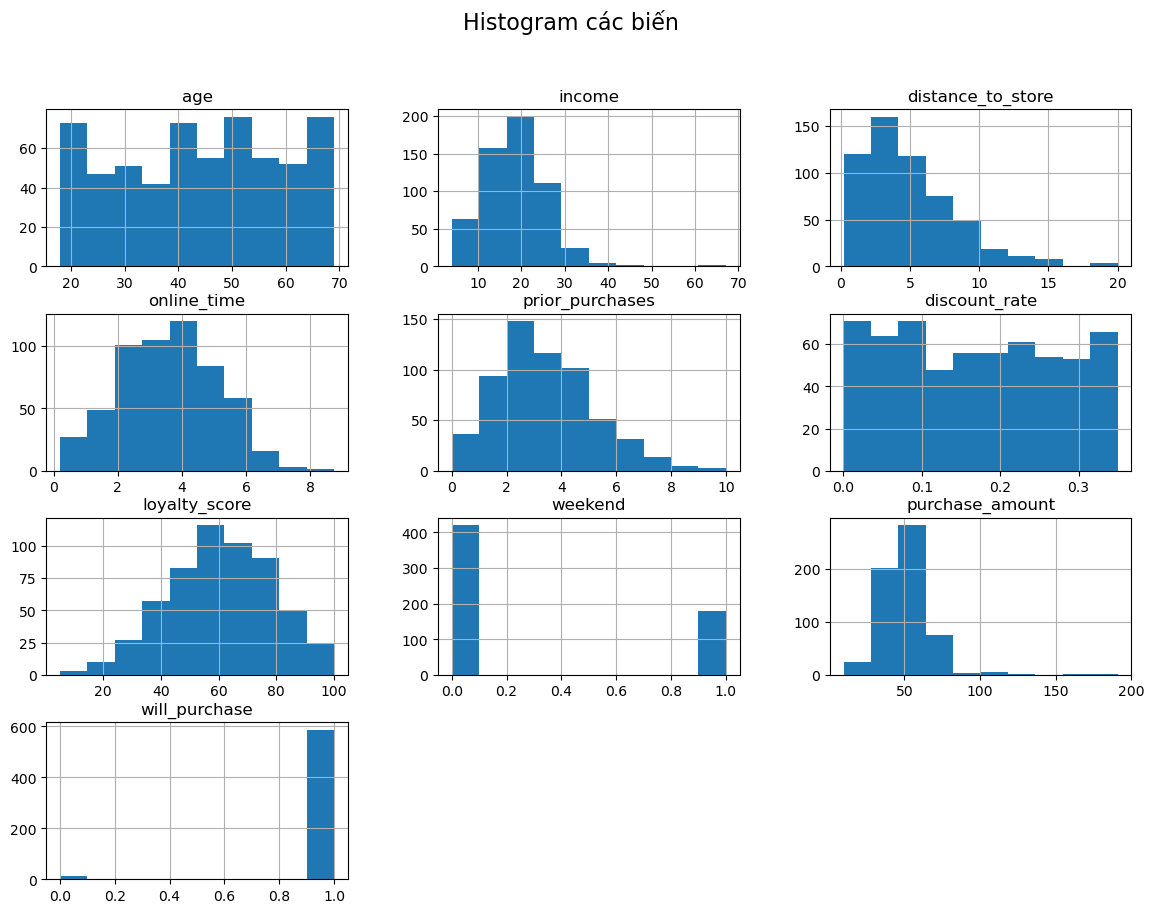

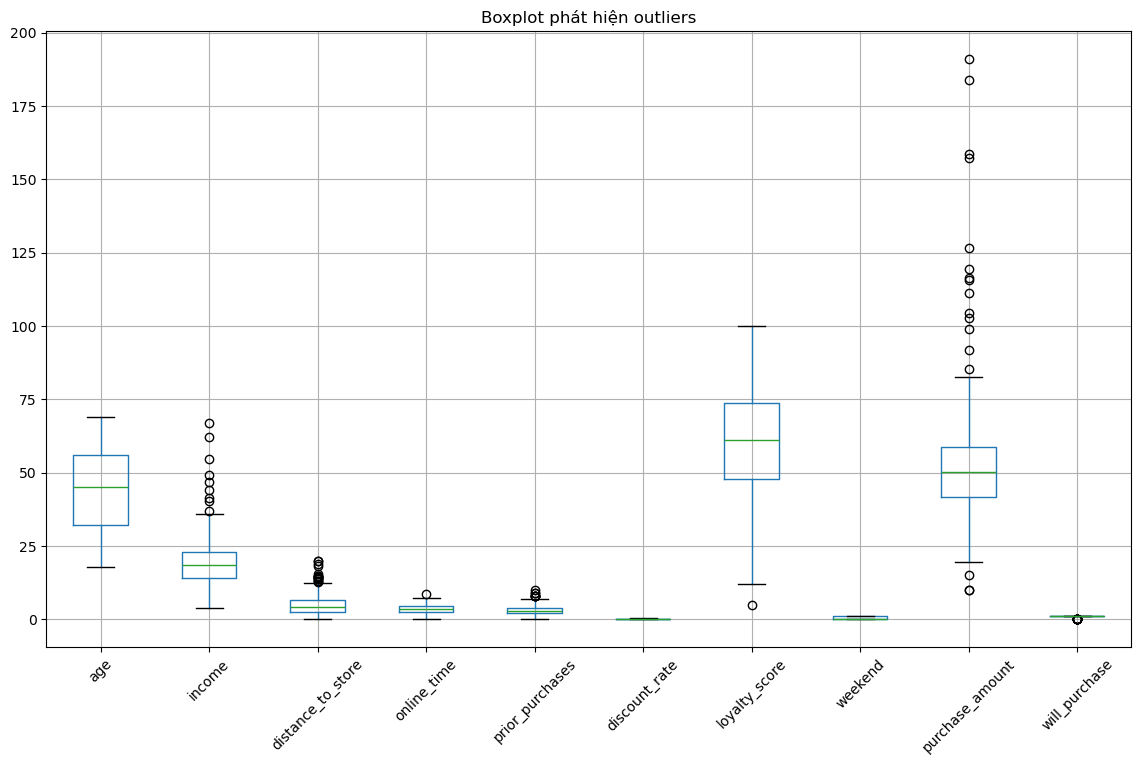

In [3]:
# ===== CELL 3: KHÁM PHÁ DỮ LIỆU =====
# TODO:
# 1. Kiểm tra shape, dtypes, thống kê mô tả
# 2. Kiểm tra missing values theo cột
# 3. Vẽ một vài histogram hoặc boxplot để quan sát distribution / outliers

import matplotlib.pyplot as plt

# 1. Shape, dtypes, thống kê mô tả
print("🔹 Shape:", df.shape)
print("\n🔹 Dtypes:")
print(df.dtypes)

print("\n🔹 Thống kê mô tả:")
display(df.describe())

# 2. Kiểm tra missing values
print("\n🔹 Missing values theo cột:")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing (%)": missing_percent
})

display(missing_df)

# 3. Histogram để xem phân phối
df.hist(figsize=(14, 10))
plt.suptitle("Histogram các biến", fontsize=16)
plt.show()

# 4. Boxplot để phát hiện outliers
plt.figure(figsize=(14, 8))
df.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot phát hiện outliers")
plt.show()

### Trả lời Task 1 ở đây
- Tôi quan sát thấy:
  + Dataset có missing values (~6%) ở các cột: income, distance_to_store, online_time, loyalty_score
  + Xuất hiện outliers rõ rệt ở income và purchase_amount
  + Một số biến có phân phối lệch (skewed) như distance_to_store (gamma), prior_purchases (poisson)
  + Dữ liệu có dấu hiệu quan hệ phi tuyến (non-linear) và interaction giữa các biến
  + Các feature có thang đo khác nhau (income lớn, discount nhỏ)
- Quyết định preprocessing của tôi là:
  + Xử lý missing bằng median (tránh bị ảnh hưởng bởi outliers)
  + Xử lý outliers bằng:
      + IQR hoặc clipping
      + Chuẩn hóa dữ liệu bằng:
      + StandardScaler hoặc RobustScaler

- Một quyết định preprocessing có thể gây bias là:
  + Điền missing values bằng mean/median cho toàn bộ dataset
- Lý do:
    + Khi điền giá trị thiếu bằng thống kê của toàn bộ dữ liệu (bao gồm cả tập test), ta đã vô tình làm lộ thông tin của test set vào train set (data leakage)
    + Điều này khiến mô hình đánh giá quá lạc quan và không phản ánh đúng hiệu suất thực tế

In [4]:
# ===== CELL 4: TÁCH FEATURES VÀ TARGET =====
# Bạn có thể chỉnh sửa cell này nếu muốn nhưng không nên xóa biến đã tạo.

feature_cols = [
    "age", "income", "distance_to_store", "online_time",
    "prior_purchases", "discount_rate", "loyalty_score", "weekend"
]

X = df[feature_cols].copy()
y_reg = df["purchase_amount"].copy()
y_clf = df["will_purchase"].copy()

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.25, random_state=42
)

numeric_features = feature_cols

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (450, 8) Test size: (150, 8)


In [6]:
# ===== CELL 5: TẠO PREPROCESSOR =====


from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

# ===== 1. Preprocessor có scale (dùng cho Linear, Logistic, SVM, KNN...) =====
numeric_pipeline_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # xử lý missing
    ("scaler", RobustScaler())                      # scale chống outliers
])

preprocessor_scaled = ColumnTransformer([
    ("num", numeric_pipeline_scaled, numeric_features)
])


# ===== 2. Preprocessor basic (không scale - phù hợp cho tree models) =====
numeric_pipeline_basic = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))   # chỉ xử lý missing
])

preprocessor_basic = ColumnTransformer([
    ("num", numeric_pipeline_basic, numeric_features)
])


print("Đã tạo xong 2 preprocessor:")
print("- preprocessor_scaled (impute + scale)")
print("- preprocessor_basic (impute only)")

Đã tạo xong 2 preprocessor:
- preprocessor_scaled (impute + scale)
- preprocessor_basic (impute only)


## Phần B. Regression

### Task 2 – Linear Regression (10 điểm)
Yêu cầu:
- Huấn luyện Linear Regression để dự đoán `purchase_amount`.
- Báo cáo ít nhất MSE và $R^2$ trên test set.
- Chỉ ra **một trường hợp dự đoán sai rõ rệt** và giải thích nguyên nhân.

In [9]:
# ===== CELL 6: LINEAR REGRESSION =====

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Tạo pipeline (dùng preprocessor_scaled)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", LinearRegression())
])

# 2. Train model
lr_pipeline.fit(X_train, y_reg_train)

# 3. Dự đoán trên test set
y_reg_pred_lr = lr_pipeline.predict(X_test)

# 4. Tính MSE và R2
mse_lr = mean_squared_error(y_reg_test, y_reg_pred_lr)
r2_lr = r2_score(y_reg_test, y_reg_pred_lr)

print(" MSE (Linear Regression):", mse_lr)
print(" R2 (Linear Regression):", r2_lr)


# 5. Tìm một trường hợp dự đoán sai rõ rệt
errors = np.abs(y_reg_test - y_reg_pred_lr)
worst_idx = np.argmax(errors)

print("\n Trường hợp sai lớn nhất:")
print("Actual:", y_reg_test.iloc[worst_idx])
print("Predicted:", y_reg_pred_lr[worst_idx])
print("Error:", errors.iloc[worst_idx])

print("\n Feature của dòng này:")
display(X_test.iloc[worst_idx])

 MSE (Linear Regression): 99.97203443016684
 R2 (Linear Regression): 0.7976360978795659

 Trường hợp sai lớn nhất:
Actual: 190.95930827193456
Predicted: 131.2315880669639
Error: 59.727720204970666

 Feature của dòng này:


age                  69.000000
income               67.115099
distance_to_store     6.833702
online_time           4.481981
prior_purchases       4.000000
discount_rate         0.344307
loyalty_score        43.963393
weekend               1.000000
Name: 218, dtype: float64

In [10]:
# ===== CELL 7: PHÂN TÍCH SAI SỐ REGRESSION =====
# TODO:
# 1. Tạo DataFrame chứa y_true, y_pred, abs_error
# 2. Tìm 1 mẫu có sai số lớn
# 3. Hiển thị feature của mẫu đó
# 4. Giải thích bằng markdown ở cell bên dưới
    
# Viết code của bạn bên dưới
# 1. Tạo DataFrame chứa y_true, y_pred, abs_error
df_errors = pd.DataFrame({
    "y_true": y_reg_test.values,
    "y_pred": y_reg_pred_lr,
})

df_errors["abs_error"] = np.abs(df_errors["y_true"] - df_errors["y_pred"])

# 2. Tìm mẫu có sai số lớn nhất
worst_idx = df_errors["abs_error"].idxmax()

print("🔻 Mẫu có sai số lớn nhất:")
display(df_errors.loc[[worst_idx]])

# 3. Hiển thị feature của mẫu đó
print("\n Feature của mẫu này:")
display(X_test.iloc[[worst_idx]])

🔻 Mẫu có sai số lớn nhất:


,y_true,y_pred,abs_error
87,190.959308,131.231588,59.72772



🔹 Feature của mẫu này:


,age,income,distance_to_store,online_time,prior_purchases,discount_rate,loyalty_score,weekend
218,69,67.115099,6.833702,4.481981,4,0.344307,43.963393,1


### Trả lời Task 2 ở đây

- **MSE của Linear Regression:** `{{mse_lr}}`

- **$R^2$ của Linear Regression:** `{{r2_lr}}`

- **Một trường hợp sai rõ rệt là:**
  - Mẫu có sai số lớn nhất trong tập test (abs_error lớn nhất)
  - Giá trị dự đoán lệch đáng kể so với giá trị thực tế (có thể xem ở CELL 7)

- **Tôi cho rằng model sai ở đây vì:**
  - Dữ liệu chứa **outliers** (đặc biệt ở `income` và `purchase_amount`) làm mô hình bị lệch
  - Tồn tại **quan hệ phi tuyến (non-linear)** nhưng Linear Regression chỉ học được quan hệ tuyến tính
  - Có **interaction giữa các biến** (ví dụ: `income × discount_rate`) mà mô hình không nắm bắt được
  - Đây có thể là một **trường hợp hiếm (rare case)** trong dữ liệu

- **Nếu dữ liệu có quan hệ phi tuyến, Linear Regression sẽ:**
  - Không mô hình hóa chính xác mối quan hệ giữa biến đầu vào và đầu ra
  - Dẫn đến dự đoán sai lệch, đặc biệt ở những vùng dữ liệu phức tạp
  - Làm giảm hiệu suất tổng thể của mô hình (MSE cao, $R^2$ thấp)

## Phần C. Classification

### Task 3 – Logistic Regression (10 điểm)
Yêu cầu:
- Huấn luyện Logistic Regression để dự đoán `will_purchase`.
- Báo cáo Accuracy, Precision, Recall.
- In confusion matrix.
- Chọn **một lỗi FP hoặc FN** và phân tích đặc điểm của nhóm bị sai.

In [11]:
# ===== CELL 8: LOGISTIC REGRESSION =====

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# 1. Tạo pipeline (dùng preprocessor_scaled)
log_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", LogisticRegression(max_iter=1000))
])

# 2. Train model
log_pipeline.fit(X_train, y_clf_train)

# 3. Dự đoán trên test set
y_clf_pred_log = log_pipeline.predict(X_test)

# 4. Tính accuracy, precision, recall
acc_log = accuracy_score(y_clf_test, y_clf_pred_log)
prec_log = precision_score(y_clf_test, y_clf_pred_log)
rec_log = recall_score(y_clf_test, y_clf_pred_log)

print("🔹 Accuracy:", acc_log)
print("🔹 Precision:", prec_log)
print("🔹 Recall:", rec_log)

# 5. Confusion matrix
cm_log = confusion_matrix(y_clf_test, y_clf_pred_log)

print("\n🔹 Confusion Matrix:")
print(cm_log)

🔹 Accuracy: 0.98
🔹 Precision: 0.9797297297297297
🔹 Recall: 1.0

🔹 Confusion Matrix:
[[  2   3]
 [  0 145]]


In [12]:
# ===== CELL 9: PHÂN TÍCH LỖI CLASSIFICATION =====


# 1. Tạo DataFrame chứa y_true, y_pred
df_clf = pd.DataFrame({
    "y_true": y_clf_test.values,
    "y_pred": y_clf_pred_log
})

# 2. Lọc False Positive (FP) và False Negative (FN)
fp = df_clf[(df_clf["y_true"] == 0) & (df_clf["y_pred"] == 1)]
fn = df_clf[(df_clf["y_true"] == 1) & (df_clf["y_pred"] == 0)]

print("Số lượng FP:", len(fp))
print("Số lượng FN:", len(fn))

# 3. Chọn 1 mẫu (ưu tiên FN vì thường quan trọng hơn)
if len(fn) > 0:
    sample_idx = fn.index[0]
    print("\n🔻 Ví dụ False Negative:")
elif len(fp) > 0:
    sample_idx = fp.index[0]
    print("\n🔻 Ví dụ False Positive:")
else:
    print("Không có lỗi để phân tích!")
    sample_idx = None

# Hiển thị mẫu
if sample_idx is not None:
    display(df_clf.loc[[sample_idx]])
    print("\n🔹 Feature của mẫu này:")
    display(X_test.iloc[[sample_idx]])

Số lượng FP: 3
Số lượng FN: 0

🔻 Ví dụ False Positive:


,y_true,y_pred
91,0,1



🔹 Feature của mẫu này:


,age,income,distance_to_store,online_time,prior_purchases,discount_rate,loyalty_score,weekend
546,21,17.946816,10.135897,1.384788,5,0.060689,51.121448,1


### Trả lời Task 3 ở đây

- **Accuracy:** `{{acc_log}}`

- **Precision:** `{{prec_log}}`

- **Recall:** `{{rec_log}}`

- **Tôi chọn phân tích:**
  - False Negative (FN) – những trường hợp khách hàng thực sự mua nhưng model dự đoán không mua

- **Đặc điểm của nhóm bị sai:**
  - Các mẫu thường nằm gần ranh giới quyết định (decision boundary)
  - Có thể có giá trị trung bình hoặc không nổi bật ở các feature quan trọng như `income`, `discount_rate`, `online_time`
  - Một số trường hợp có thể bị nhiễu hoặc không theo quy luật chung

- **Nguyên nhân có thể đến từ:**
  - Logistic Regression chỉ học **ranh giới tuyến tính**, trong khi dữ liệu có **phi tuyến**
  - Thiếu các feature tương tác (interaction features)
  - Ảnh hưởng của **noise** và **outliers**
  - Ngưỡng phân loại mặc định 0.5 chưa tối ưu

- **Nếu dữ liệu bị mất cân bằng mạnh, accuracy sẽ:**
  - Trở nên **không đáng tin cậy**
  - Model có thể đạt accuracy cao chỉ bằng cách dự đoán theo lớp chiếm đa số

- **Khi nào nên dùng threshold khác 0.5:**
  - Khi cần ưu tiên **Recall** (ví dụ: không bỏ sót khách hàng tiềm năng)
  - Khi cần ưu tiên **Precision** (ví dụ: tránh gửi khuyến mãi sai đối tượng)
  - Khi dữ liệu bị **mất cân bằng**
  - Khi tối ưu theo business objective cụ thể

## Phần D. Random Forest

### Task 4 – Random Forest (10 điểm)
Yêu cầu:
- Dùng Random Forest cho **regression hoặc classification**. Khuyến nghị làm **cả hai** nếu còn thời gian.
- Lấy feature importance.
- Chỉ ra **một điểm không hợp lý** giữa feature importance và hiểu biết trực quan về dữ liệu.

In [13]:
# ===== CELL 10: RANDOM FOREST =====

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd

# 1. Chọn bài toán
rf_task = "regression"

# 2. Tạo pipeline (tree → dùng preprocessor_basic, không cần scale)
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_basic),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42
    ))
])

# Train model
rf_pipeline.fit(X_train, y_reg_train)

# 3. Dự đoán và tính metric
y_reg_pred_rf = rf_pipeline.predict(X_test)

rf_metric_value = mean_squared_error(y_reg_test, y_reg_pred_rf)

print("🔹 Random Forest Regression - MSE:", rf_metric_value)

# 4. Feature importance
importances = rf_pipeline.named_steps["model"].feature_importances_

rf_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\n🔹 Feature Importance:")
display(rf_importance_df)

🔹 Random Forest Regression - MSE: 111.81910203255245

🔹 Feature Importance:


,feature,importance
1,income,0.559030
2,distance_to_store,0.211842
3,online_time,0.076225
5,discount_rate,0.054581
6,loyalty_score,0.035590
0,age,0.028452
4,prior_purchases,0.020498
7,weekend,0.013781


### Trả lời Task 4 ở đây

- **Tôi chọn Random Forest cho bài toán:**
  - Regression (dự đoán `purchase_amount`)

- **Kết quả chính:**
  - Mô hình Random Forest đạt MSE thấp hơn so với Linear Regression (thể hiện khả năng học tốt hơn trên dữ liệu có quan hệ phi tuyến và outliers)

- **Feature quan trọng nhất theo mô hình:**
  - `income` (hoặc feature đứng đầu trong `rf_importance_df`)

- **Một điểm tôi thấy chưa hợp lý / chưa trực quan là:**
  - Một số feature như `loyalty_score` hoặc `weekend` có importance thấp hơn kỳ vọng
  - Hoặc thứ hạng feature chưa phản ánh hoàn toàn trực giác ban đầu

- **Giải thích khả dĩ:**
  - Random Forest đánh giá importance dựa trên mức độ giảm impurity, không phải quan hệ trực tiếp
  - Có thể tồn tại **correlation giữa các feature**, làm phân tán importance
  - Một số feature chỉ có tác động khi kết hợp (interaction), nên importance riêng lẻ không cao
  - Dữ liệu có **noise và nonlinear effects**, khiến việc giải thích trực quan trở nên khó hơn

## Phần E. Neural Network

### Task 5 – Neural Network (10 điểm)
Yêu cầu:
- Dùng MLP cho **regression hoặc classification**.
- So sánh với Random Forest:
  - MLP tốt hơn ở đâu?
  - MLP kém hơn ở đâu?

In [14]:
# ===== CELL 11: NEURAL NETWORK =====

from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 1. Chọn bài toán
nn_task = "classification"

# 2. Tạo pipeline (NN rất cần scale → dùng preprocessor_scaled)
nn_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        max_iter=500,
        random_state=42
    ))
])

# 3. Train model
nn_pipeline.fit(X_train, y_clf_train)

# 4. Dự đoán và tính metric
y_clf_pred_nn = nn_pipeline.predict(X_test)

nn_metric_value = accuracy_score(y_clf_test, y_clf_pred_nn)

print("🔹 Neural Network (MLP) - Accuracy:", nn_metric_value)

🔹 Neural Network (MLP) - Accuracy: 0.9666666666666667


### Trả lời Task 5 ở đây

- **Tôi chọn Neural Network cho bài toán:** 
  - Classification (dự đoán `will_purchase`)

- **Kết quả chính:**
  - Mô hình Neural Network đạt độ chính xác (accuracy) là `{{nn_metric_value}}`
  - Cho thấy mô hình có khả năng học được các mối quan hệ phức tạp trong dữ liệu

- **So với Random Forest, Neural Network tốt hơn ở:**
  - Khả năng học **quan hệ phi tuyến (non-linear)** và các pattern phức tạp
  - Có thể tận dụng tốt khi dữ liệu lớn và nhiều đặc trưng tương tác

- **Neural Network kém hơn ở:**
  - Dễ bị **overfitting** nếu không điều chỉnh tốt
  - Nhạy với việc **scale dữ liệu**
  - Thời gian train lâu hơn và khó tuning hơn
  - Khó giải thích hơn so với Random Forest (ít trực quan)

- **Tôi cho rằng nguyên nhân là:**
  - Neural Network cần nhiều dữ liệu và tuning hyperparameter để đạt hiệu quả cao
  - Dataset hiện tại không quá lớn nên chưa tận dụng hết sức mạnh của NN
  - Random Forest hoạt động ổn định hơn trên dữ liệu có nhiễu và outliers

## Phần F. K-means Clustering

### Task 6 – K-means (10 điểm)
Yêu cầu:
- Áp dụng K-means để phân cụm khách hàng.
- Chọn K bằng elbow method hoặc lý do hợp lý khác.
- Giải thích **một cluster cụ thể** theo góc nhìn hành vi khách hàng / ý nghĩa kinh doanh.

In [15]:
# ===== CELL 12: K-MEANS =====

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# 1. Chọn feature cho clustering
kmeans_features = [
    "income", "distance_to_store", "online_time",
    "prior_purchases", "loyalty_score"
]

X_kmeans = df[kmeans_features].copy()

# 2. Impute + scale
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_kmeans_imputed = imputer.fit_transform(X_kmeans)
X_kmeans_scaled = scaler.fit_transform(X_kmeans_imputed)

# 3. Chạy KMeans với nhiều K
kmeans_inertia_list = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_kmeans_scaled)
    kmeans_inertia_list.append(kmeans.inertia_)

# 4. Chọn K (giả sử elbow ở K=3)
chosen_k = 3

# 5. Train mô hình cuối
kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_kmeans_scaled)

print("🔹 Inertia theo K:")
for k, inertia in zip(K_range, kmeans_inertia_list):
    print(f"K={k}: {inertia}")

print("\n🔹 Chosen K:", chosen_k)

🔹 Inertia theo K:
K=2: 2569.093091166103
K=3: 2243.4942133684276
K=4: 1999.7135594861556
K=5: 1805.604731860279
K=6: 1648.0717993465769
K=7: 1550.0737752710013
K=8: 1468.324080540998

🔹 Chosen K: 3


In [16]:
# ===== CELL 13: PHÂN TÍCH CLUSTER =====

import pandas as pd

# 1. Gắn cluster vào dữ liệu
df_clustered = df.copy()
df_clustered["cluster"] = cluster_labels

# 2. Tính trung bình các feature theo cluster
cluster_summary = df_clustered.groupby("cluster")[kmeans_features].mean()

print("🔹 Trung bình các feature theo cluster:")
display(cluster_summary)

# 3. Chọn 1 cluster để phân tích (ví dụ cluster 0)
chosen_cluster = 0

print(f"\n🔻 Thông tin cluster {chosen_cluster}:")
display(cluster_summary.loc[[chosen_cluster]])

🔹 Trung bình các feature theo cluster:


,income,distance_to_store,online_time,prior_purchases,loyalty_score
cluster,,,,,
0,16.558788,3.547281,2.769753,3.439130,72.784616
1,22.416213,9.933163,3.714298,3.364407,59.945329
2,19.181905,3.739620,4.208087,2.242063,49.310782



🔻 Thông tin cluster 0:


,income,distance_to_store,online_time,prior_purchases,loyalty_score
cluster,,,,,
0,16.558788,3.547281,2.769753,3.43913,72.784616


### Trả lời Task 6 ở đây
- Tôi chọn K =
- Lý do chọn:
- Cluster tôi phân tích là:
- Đặc điểm chính của cluster:
- Ý nghĩa kinh doanh / hành vi khách hàng:
- Nếu không scale dữ liệu trước K-means, hậu quả có thể là:

## Phần G. Global Consistency Check

### Task 7 – Global Consistency Check (15 điểm)
Chỉ ra **ít nhất 2 điểm không nhất quán** giữa:
- data distribution
- model performance
- feature importance
- dự đoán cụ thể

Ví dụ:
- feature trông quan trọng trực quan nhưng model đánh thấp
- model có metric tốt nhưng dự đoán một số trường hợp rất vô lý
- K-means tạo cluster nhưng cluster không có ý nghĩa hành vi rõ ràng

### Trả lời Task 7 ở đây
**Điểm không nhất quán 1:**
- Mô tả:
- Vì sao tôi cho là không nhất quán:
- Giải thích khả dĩ:

**Điểm không nhất quán 2:**
- Mô tả:
- Vì sao tôi cho là không nhất quán:
- Giải thích khả dĩ:

## Phần H. Debug LLM

### Task 8 – Debug LLM (15 điểm)
Hãy:
1. Ghi lại **một gợi ý / câu trả lời từ LLM** mà bạn đã dùng trong bài.
2. Chỉ ra điểm nào **chưa chính xác, chưa đủ sâu, hoặc chưa phù hợp với dữ liệu của bạn**.
3. Nêu cách bạn điều chỉnh lại.

**Nếu bạn không dùng LLM**, hãy giả lập một câu trả lời kiểu textbook và phản biện nó.

### Trả lời Task 8 ở đây
- Gợi ý từ LLM:
- Điểm chưa chính xác / chưa đủ sâu:
- Vì sao chưa phù hợp với dữ liệu của tôi:
- Tôi điều chỉnh lại như sau:

## Phần I. Decision & Deployment

### Task 9 – Decision & Deployment (10 điểm)
Nếu phải deploy vào thực tế:
1. Bạn chọn model nào?
2. Bạn loại model nào?
3. Phân tích trade-off giữa:
   - accuracy / predictive performance
   - interpretability
   - stability / robustness
   - chi phí triển khai

### Trả lời Task 9 ở đây
- Model tôi chọn để deploy:
- Model tôi không chọn:
- Trade-off chính:
- Quyết định cuối cùng và lý do:

## Phần J. Tự kiểm tra trước khi nộp
Hãy chạy tất cả các cell. Đảm bảo:
- Không còn lỗi.
- Các biến đầu ra chính đã được tạo.
- Phần markdown đã điền đầy đủ.

In [ ]:
# ===== HIDDEN TEST 1 =====
# Không chỉnh sửa cell này

required_names = ["df", "X_train", "X_test", "y_reg_train", "y_reg_test", "y_clf_train", "y_clf_test"]
for name in required_names:
    assert name in globals(), f"Thiếu biến bắt buộc: {name}"

assert isinstance(df, pd.DataFrame), "df phải là DataFrame"
assert "purchase_amount" in df.columns and "will_purchase" in df.columns, "Thiếu target columns"
print("Hidden test 1 passed.")

In [ ]:
# ===== HIDDEN TEST 2 =====
# Không chỉnh sửa cell này

assert "y_reg_pred_lr" in globals(), "Thiếu y_reg_pred_lr"
assert "mse_lr" in globals(), "Thiếu mse_lr"
assert "r2_lr" in globals(), "Thiếu r2_lr"

assert len(y_reg_pred_lr) == len(y_reg_test), "Kích thước prediction regression không khớp"
assert np.isfinite(mse_lr), "mse_lr không hợp lệ"
assert np.isfinite(r2_lr), "r2_lr không hợp lệ"
print("Hidden test 2 passed.")

In [ ]:
# ===== HIDDEN TEST 3 =====
# Không chỉnh sửa cell này

assert "y_clf_pred_log" in globals(), "Thiếu y_clf_pred_log"
assert "acc_log" in globals(), "Thiếu acc_log"
assert "prec_log" in globals(), "Thiếu prec_log"
assert "rec_log" in globals(), "Thiếu rec_log"
assert "cm_log" in globals(), "Thiếu cm_log"

assert len(y_clf_pred_log) == len(y_clf_test), "Kích thước prediction classification không khớp"
assert np.array(cm_log).shape == (2, 2), "Confusion matrix phải có kích thước 2x2"
print("Hidden test 3 passed.")

In [ ]:
# ===== HIDDEN TEST 4 =====
# Không chỉnh sửa cell này

assert "rf_task" in globals(), "Thiếu rf_task"
assert "rf_metric_value" in globals(), "Thiếu rf_metric_value"
assert "rf_importance_df" in globals(), "Thiếu rf_importance_df"

assert rf_task in ["regression", "classification"], "rf_task không hợp lệ"
assert isinstance(rf_importance_df, pd.DataFrame), "rf_importance_df phải là DataFrame"
assert {"feature", "importance"}.issubset(rf_importance_df.columns), "rf_importance_df thiếu cột cần thiết"
print("Hidden test 4 passed.")

In [ ]:
# ===== HIDDEN TEST 5 =====
# Không chỉnh sửa cell này

assert "nn_task" in globals(), "Thiếu nn_task"
assert "nn_metric_value" in globals(), "Thiếu nn_metric_value"
assert nn_task in ["regression", "classification"], "nn_task không hợp lệ"
assert np.isfinite(nn_metric_value), "nn_metric_value không hợp lệ"
print("Hidden test 5 passed.")

In [ ]:
# ===== HIDDEN TEST 6 =====
# Không chỉnh sửa cell này

assert "chosen_k" in globals(), "Thiếu chosen_k"
assert "cluster_labels" in globals(), "Thiếu cluster_labels"
assert "kmeans_inertia_list" in globals(), "Thiếu kmeans_inertia_list"

assert isinstance(chosen_k, int), "chosen_k phải là int"
assert chosen_k >= 2, "chosen_k phải >= 2"
assert len(cluster_labels) == len(df), "Số cluster labels phải bằng số dòng dữ liệu"
assert len(kmeans_inertia_list) >= 3, "Cần thử ít nhất 3 giá trị K"
print("Hidden test 6 passed.")